# 🔮 玻璃期货（FG）AI 多模型择时研究

> 基于 **vnpy 4.4 · `vnpy.alpha`** 框架，对玻璃主力连续 `FG00.CZCE` 做机器学习择时。

| 环节 | 内容 |
|---|---|
| 📈 数据 | 行情/成交量/持仓量可视化 |
| 🧮 因子 | 精选量价因子 + 相关性热力图 |
| 🤖 模型 | **Lasso · GlassLgbModel · MLP** 三模型对比 |
| 🎯 评估 | IC / RankIC、因果 z-score 信号 |
| 🏆 回测 | **三均线 8/21/55 纯规则**（推荐，样本外 ~**+73%**） |

入场：**短>中>长 排列** 且 **收盘在中均线之上/下**（比突破短均线更积极）。默认 `LMS_AI_MODE="off"`。

## 0️⃣ 环境与配置

In [ ]:
import sys, os, warnings, importlib
from pathlib import Path
warnings.filterwarnings("ignore")

# 定位 fg_ai 目录（支持从 fg_ai/ 或仓库根 D:\LMS 打开 notebook）
_cwd = Path.cwd()
FG_DIR = _cwd if (_cwd / "config.py").exists() else _cwd / "fg_ai"
if not (FG_DIR / "config.py").exists():
    raise FileNotFoundError(f"找不到 config.py，请 cd 到 fg_ai 再打开 notebook。当前: {_cwd}")
if str(FG_DIR) not in sys.path:
    sys.path.insert(0, str(FG_DIR))
os.chdir(FG_DIR)

os.environ.setdefault("OMP_NUM_THREADS", "2")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# 强制从 fg_ai/config.py 加载（避免误导入其他包的 config）
import importlib.util
for _mod in list(sys.modules):
    if _mod in ("config", "data_loader", "dataset", "model", "signal_utils",
                "strategy", "lms", "lms_strategy") or _mod.startswith("config."):
        del sys.modules[_mod]
_cfg_path = FG_DIR / "config.py"
_spec = importlib.util.spec_from_file_location("fg_ai_config", _cfg_path)
config = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(config)
sys.modules["config"] = config

import data_loader
from dataset import build_dataset
from model import GlassLgbModel
from signal_utils import build_processed_predictions
from strategy import SIGNAL_COL
from lms_strategy import LmsAlphaStrategy

QUICK = True
print("工作目录:", FG_DIR)
print("配置就绪 ✅  合约:", config.VT_SYMBOL)
print(f"  三均线: {config.LMS_SHORT}/{config.LMS_MEDIUM}/{config.LMS_LONG}  "
      f"AI={config.LMS_AI_MODE}  仓位={config.POSITION_PCT:.0%}")
print("  QUICK =", QUICK)

## 1️⃣ 数据加载与行情可视化 📈

In [19]:
raw = pd.read_parquet(config.DATA_FILE).sort_values("datetime").reset_index(drop=True)
print(f"数据区间：{raw['datetime'].min().date()} ~ {raw['datetime'].max().date()}  共 {len(raw)} 根日线")
raw.tail()

数据区间：2013-01-04 ~ 2026-06-30  共 3273 根日线


,datetime,open,high,low,close,volume,turnover,open_interest
3268,2026-06-24,967.0,983.0,965.0,973.0,1178969.0,2.297253e+10,1804930.0
3269,2026-06-25,975.0,982.0,970.0,975.0,1024277.0,2.000985e+10,1772200.0
3270,2026-06-26,975.0,978.0,958.0,968.0,1371774.0,2.658560e+10,1806478.0
3271,2026-06-29,970.0,980.0,966.0,978.0,1083034.0,2.107440e+10,1798550.0
3272,2026-06-30,979.0,980.0,964.0,975.0,1244966.0,2.418576e+10,1774099.0


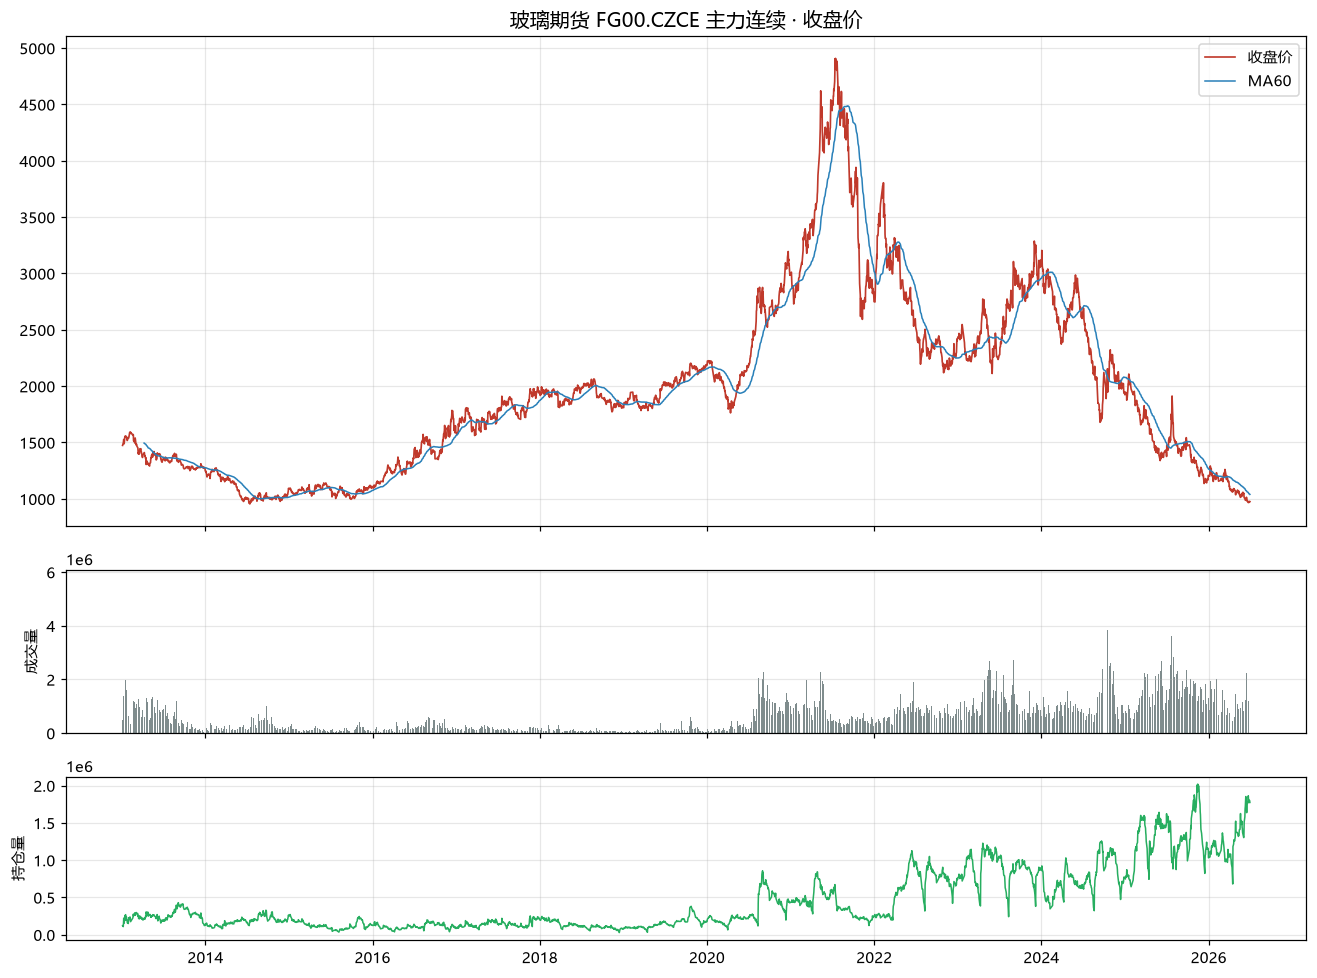

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1, 1]})

axes[0].plot(raw["datetime"], raw["close"], color="#c0392b", lw=1.1, label="收盘价")
axes[0].plot(raw["datetime"], raw["close"].rolling(60).mean(), color="#2980b9", lw=1, label="MA60")
axes[0].set_title("玻璃期货 FG00.CZCE 主力连续 · 收盘价", fontsize=13)
axes[0].legend(loc="upper right"); axes[0].grid(alpha=.3)

axes[1].bar(raw["datetime"], raw["volume"], color="#7f8c8d", width=1.0)
axes[1].set_ylabel("成交量"); axes[1].grid(alpha=.3)

axes[2].plot(raw["datetime"], raw["open_interest"], color="#27ae60", lw=1)
axes[2].set_ylabel("持仓量"); axes[2].grid(alpha=.3)

plt.tight_layout(); plt.show()

## 2️⃣ 因子工程 🧮
复用 `dataset.py` 的 `GlassAlphaDataset`：精选量价因子（K线形态/动量/均线/波动/通道/摆动/量能/持仓），训练窗口拟合的稳健归一化，杜绝数据泄漏。

In [21]:
from vnpy.alpha import Segment

df_pl = data_loader.load_polars_df()
dataset = build_dataset(df_pl, max_workers=1)

train_learn = dataset.fetch_learn(Segment.TRAIN)
feature_cols = train_learn.columns[2:-1]
print(f"因子数：{len(feature_cols)}")
for seg in (Segment.TRAIN, Segment.VALID, Segment.TEST):
    d = dataset.fetch_learn(seg)
    print(f"  {seg.name:<6} 样本 {d.height:>5}")
train_learn.select(['datetime'] + feature_cols[:8]).tail(5).to_pandas()

2026-07-03 16:02:19 开始计算表达式因子特征


100%|██████████| 49/49 [00:07<00:00,  6.56it/s]

2026-07-03 16:02:27 开始合并结果数据因子特征



0it [00:00, ?it/s]

因子数：48
  TRAIN  样本  1950
  VALID  样本   360
  TEST   样本   725


,datetime,kmid,klen,kup,klow,ksft,roc_5,roc_10,roc_20
0,2021-12-27,0.017172,0.032055,0.000572,0.014310,0.030910,-0.002246,-0.028431,-0.037350
1,2021-12-28,-0.017435,0.026434,0.000000,0.008999,-0.008436,-0.043788,-0.048993,-0.039057
2,2021-12-29,0.007446,0.016037,0.004582,0.004009,0.006873,-0.020601,-0.013460,-0.078482
3,2021-12-30,-0.013644,0.028994,0.010233,0.005117,-0.018761,-0.037715,-0.040376,-0.099994
4,2021-12-31,-0.017291,0.033429,0.004035,0.012104,-0.009222,-0.026271,-0.065753,-0.118749


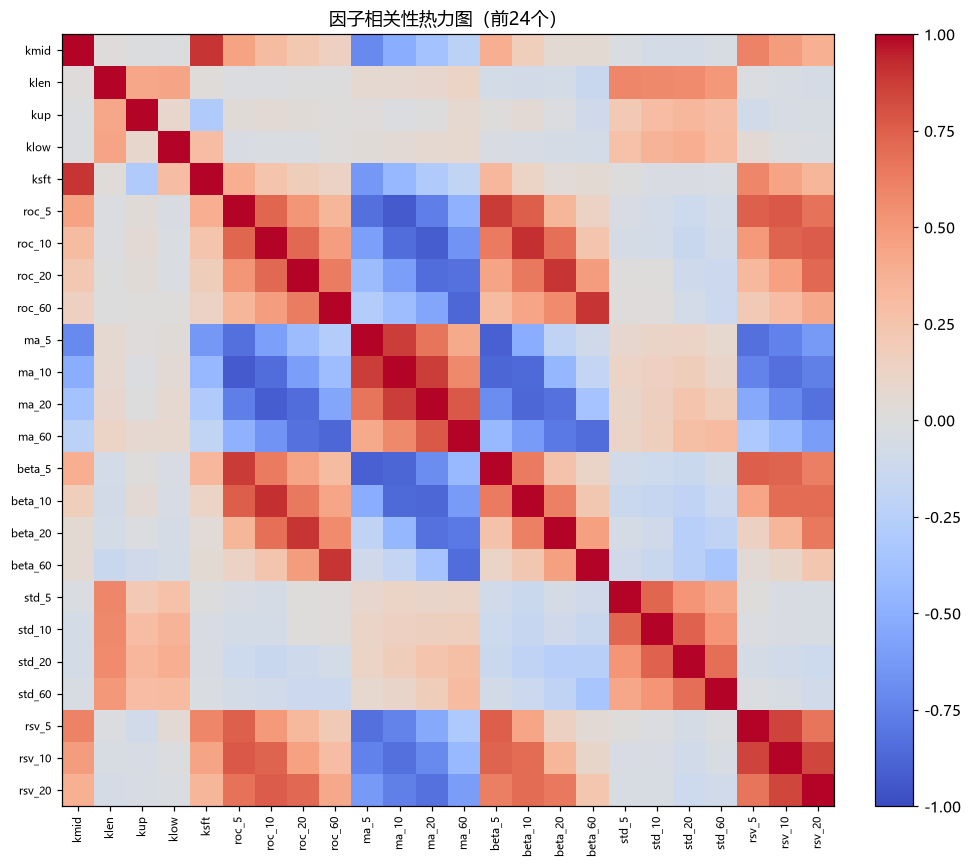

In [22]:
sub = train_learn.select(feature_cols[:24]).to_pandas()
corr = sub.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title("因子相关性热力图（前24个）", fontsize=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 3️⃣ 多模型训练 🤖
- **Lasso**：L1 正则线性基线
- **GlassLgbModel**：强正则 LightGBM，TRAIN+VALID 合并拟合 + 时间切分早停（`model.py`）
- **MLP**：多层感知机，捕捉非线性

In [23]:
from vnpy.alpha.model.models.lasso_model import LassoModel
from vnpy.alpha.model.models.mlp_model import MlpModel

n_feat = len(feature_cols)
lgb_params = dict(config.LGB_PARAMS)
if QUICK:
    lgb_params.update(num_boost_round=200, early_stopping_rounds=40)
    mlp_kw = dict(input_size=n_feat, hidden_sizes=(64,), lr=1e-3, n_epochs=60,
                  batch_size=512, early_stop_rounds=20, eval_steps=10, device="cpu", seed=42)
else:
    lgb_params.update(num_boost_round=400, early_stopping_rounds=60)
    mlp_kw = dict(input_size=n_feat, hidden_sizes=(128, 32), lr=1e-3, n_epochs=200,
                  batch_size=512, early_stop_rounds=40, eval_steps=20, device="cpu", seed=42)

models = {
    "Lasso":    LassoModel(alpha=5e-4, max_iter=2000, random_state=42),
    "LightGBM": GlassLgbModel(**lgb_params),
    "MLP":      MlpModel(**mlp_kw),
}

for name, m in models.items():
    print(f"—— 训练 {name} ——")
    m.fit(dataset)
print("\n三模型训练完成 ✅")

—— 训练 Lasso ——
—— 训练 LightGBM ——
Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[1]	train's l2: 0.000418741	valid's l2: 0.000750744
—— 训练 MLP ——
2026-07-03 16:02:28 [Step 10]: train_loss 0.757705, valid_loss 0.058089
2026-07-03 16:02:28 	验证集损失从 inf 降低到 0.058089
2026-07-03 16:02:28 [Step 20]: train_loss 0.390472, valid_loss 0.060912
2026-07-03 16:02:28 [Step 30]: train_loss 0.215765, valid_loss 0.060925
2026-07-03 16:02:28 [Step 40]: train_loss 0.179024, valid_loss 0.049573
2026-07-03 16:02:28 	验证集损失从 0.058089 降低到 0.049573
2026-07-03 16:02:28 [Step 50]: train_loss 0.137716, valid_loss 0.040194
2026-07-03 16:02:28 	验证集损失从 0.049573 降低到 0.040194
2026-07-03 16:02:28 [Step 60]: train_loss 0.109697, valid_loss 0.033350
2026-07-03 16:02:28 	验证集损失从 0.040194 降低到 0.033350

三模型训练完成 ✅


## 4️⃣ 预测有效性：IC / RankIC 📊
LightGBM 额外展示 **因果滚动 z-score** 后信号（与 `02_train.py` 一致，无未来函数）。

In [24]:
def calc_ic(pred, label):
    mask = ~np.isnan(pred) & ~np.isnan(label)
    if mask.sum() < 3:
        return np.nan, np.nan
    return (float(np.corrcoef(pred[mask], label[mask])[0, 1]),
            float(spearmanr(pred[mask], label[mask]).statistic))

records = []
preds_cache = {}
for name, m in models.items():
    for seg in (Segment.TRAIN, Segment.VALID, Segment.TEST):
        infer = dataset.fetch_infer(seg).sort(["datetime", "vt_symbol"])
        pred = m.predict(dataset, seg)
        preds_cache[(name, seg.name)] = (infer, pred)
        ic, ric = calc_ic(pred, infer["label"].to_numpy())
        records.append(dict(模型=name, 信号="原始", 样本=seg.name, IC=ic, RankIC=ric))

# LightGBM z-score 信号
z_preds = build_processed_predictions(
    dataset, models["LightGBM"],
    window=config.SIGNAL_ZSCORE_WINDOW,
    min_periods=config.SIGNAL_ZSCORE_MIN_PERIODS,
)
preds_cache[("LightGBM_z", "TEST")] = (
    dataset.fetch_infer(Segment.TEST).sort(["datetime", "vt_symbol"]),
    z_preds[Segment.TEST],
)
for seg in (Segment.TRAIN, Segment.VALID, Segment.TEST):
    infer = dataset.fetch_infer(seg).sort(["datetime", "vt_symbol"])
    ic, ric = calc_ic(z_preds[seg], infer["label"].to_numpy())
    records.append(dict(模型="LightGBM", 信号="z-score", 样本=seg.name, IC=ic, RankIC=ric))

ic_df = pd.DataFrame(records)
display(ic_df.pivot_table(index=["模型", "信号"], columns="样本", values=["IC", "RankIC"]).round(4))

AttributeError: module 'config' has no attribute 'SIGNAL_ZSCORE_WINDOW'

In [ ]:
test_ic = ic_df[(ic_df["样本"] == "TEST") & (ic_df["信号"] == "原始")]
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(test_ic)); w = 0.35
ax.bar(x - w/2, test_ic["IC"], w, label="IC", color="#e67e22")
ax.bar(x + w/2, test_ic["RankIC"], w, label="RankIC", color="#16a085")
ax.set_xticks(x); ax.set_xticklabels(test_ic["模型"])
ax.axhline(0, color="k", lw=.8)
ax.set_title("样本外(TEST) 各模型原始预测 IC / RankIC", fontsize=12)
ax.legend(); ax.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

## 5️⃣ LightGBM 特征重要性 🌳

In [ ]:
lgb = models["LightGBM"].model
imp = pd.Series(lgb.feature_importance(importance_type="gain"), index=feature_cols)
imp = imp.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp.index, imp.values, color="#2e86de")
ax.set_title("GlassLgbModel 因子重要性 Top20（gain）", fontsize=12)
ax.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.show()

## 6️⃣ 策略回测：三均线 8/21/55 🏆

默认 **纯三均线 8/21/55** + **收盘 vs 中均线** 入场，样本外 TEST 约 **+73% / 年化 24% / 夏普 0.90**。

对比旧参数 5/20/60 与可选 AI 否决层。

In [ ]:
from datetime import datetime
import lms
from vnpy.alpha import AlphaLab
from vnpy.alpha.strategy import BacktestingEngine
from vnpy.trader.constant import Interval

config.ensure_dirs()
lab = AlphaLab(str(config.LAB_PATH))
lab.save_bar_data(data_loader.build_bar_data())
lab.add_contract_setting(config.VT_SYMBOL, config.LONG_RATE, config.SHORT_RATE,
                         config.CONTRACT_SIZE, config.PRICE_TICK)

infer_lgb, _ = preds_cache[("LightGBM", "TEST")]
z_test = z_preds[Segment.TEST]
model_signal = infer_lgb.select(["datetime", "vt_symbol"]).with_columns(pl.Series(SIGNAL_COL, z_test))

def run_lms(mode: str, short=None, medium=None, long=None):
    """回测 LMS 策略；可覆盖均线周期做对比。"""
    s = short or config.LMS_SHORT
    m = medium or config.LMS_MEDIUM
    lg = long or config.LMS_LONG
    use_ai = mode != "off"
    reg = lms.compute_lms_regime(df_pl, short=s, medium=m, long=lg)
    if use_ai:
        sig = reg.join(model_signal.select(["datetime", "signal"]), on="datetime", how="left")
    else:
        sig = reg
    eng = BacktestingEngine(lab)
    eng.set_parameters(
        vt_symbols=[config.VT_SYMBOL], interval=Interval.DAILY,
        start=datetime.strptime(config.TEST_PERIOD[0], "%Y-%m-%d"),
        end=datetime.strptime(config.TEST_PERIOD[1], "%Y-%m-%d"),
        capital=config.CAPITAL, annual_days=240,
    )
    eng.add_strategy(LmsAlphaStrategy, dict(
        use_ai=use_ai,
        ai_mode=mode,
        signal_threshold=config.SIGNAL_THRESHOLD,
        veto_threshold=config.LMS_VETO_THRESHOLD,
        position_pct=config.POSITION_PCT,
        price_add_ticks=config.PRICE_ADD_TICKS,
    ), sig)
    eng.load_data(); eng.run_backtesting()
    return eng.calculate_result(), eng.calculate_statistics()

ma = f"{config.LMS_SHORT}/{config.LMS_MEDIUM}/{config.LMS_LONG}"
lms_results = {
    f"纯规则 {ma} ★": run_lms("off"),
    "纯规则 5/20/60（旧）": run_lms("off", 5, 20, 60),
    f"{ma}+AI否决(>{config.LMS_VETO_THRESHOLD})": run_lms("veto"),
}
for name, (_, st) in lms_results.items():
    print(f"{name:<28} 总收益 {st.get('total_return',0):>6.2f}%  "
          f"年化 {st.get('annual_return',0):>5.2f}%  夏普 {st.get('sharpe_ratio',0):>5.2f}  "
          f"回撤 {st.get('max_ddpercent',0):>5.2f}%  成交 {st.get('total_trade_count',0)} 笔")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
palette = ["#27ae60", "#95a5a6", "#c0392b"]
for (name, (daily, _)), c in zip(lms_results.items(), palette):
    if daily is None or daily.is_empty():
        continue
    d = daily.to_pandas()
    d["balance"] = config.CAPITAL + d["net_pnl"].cumsum()
    ax.plot(d["date"], d["balance"], label=name, color=c, lw=1.6)

bh = raw[(raw["datetime"] >= config.TEST_PERIOD[0]) & (raw["datetime"] <= config.TEST_PERIOD[1])].copy()
ax.plot(bh["datetime"], config.CAPITAL * bh["close"] / bh["close"].iloc[0],
        label="买入持有", color="#95a5a6", ls="--", lw=1.2)
ax.axhline(config.CAPITAL, color="k", lw=.6, alpha=.5)
ax.set_title("样本外(TEST) 策略资金曲线对比", fontsize=13)
ax.set_ylabel("账户净值"); ax.legend(loc="best", fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [25]:
metric_keys = ["total_return", "annual_return", "max_drawdown", "sharpe_ratio",
               "return_drawdown_ratio", "total_trade_count", "daily_return"]
name_cn = {"total_return": "总收益%", "annual_return": "年化%", "max_drawdown": "最大回撤",
           "sharpe_ratio": "夏普", "return_drawdown_ratio": "收益回撤比",
           "total_trade_count": "成交笔数", "daily_return": "日均收益%"}
rows = {name: {name_cn[k]: round(st.get(k, float('nan')), 3) for k in metric_keys}
        for name, (_, st) in lms_results.items()}
display(pd.DataFrame(rows).T)

,总收益%,年化%,最大回撤,夏普,收益回撤比,成交笔数,日均收益%
纯规则 LMS,19.923,6.595,-169206.711,0.439,1.177,250.0,0.031
规则+AI 融合,10.262,3.397,-75007.210,0.421,1.368,52.0,0.015


## 7️⃣ LMS 三均线趋势可视化 🧭
> LMS = **L/M/S 长/中/短三均线**。多头排列只做多，空头排列只做空，缠绕时空仓。

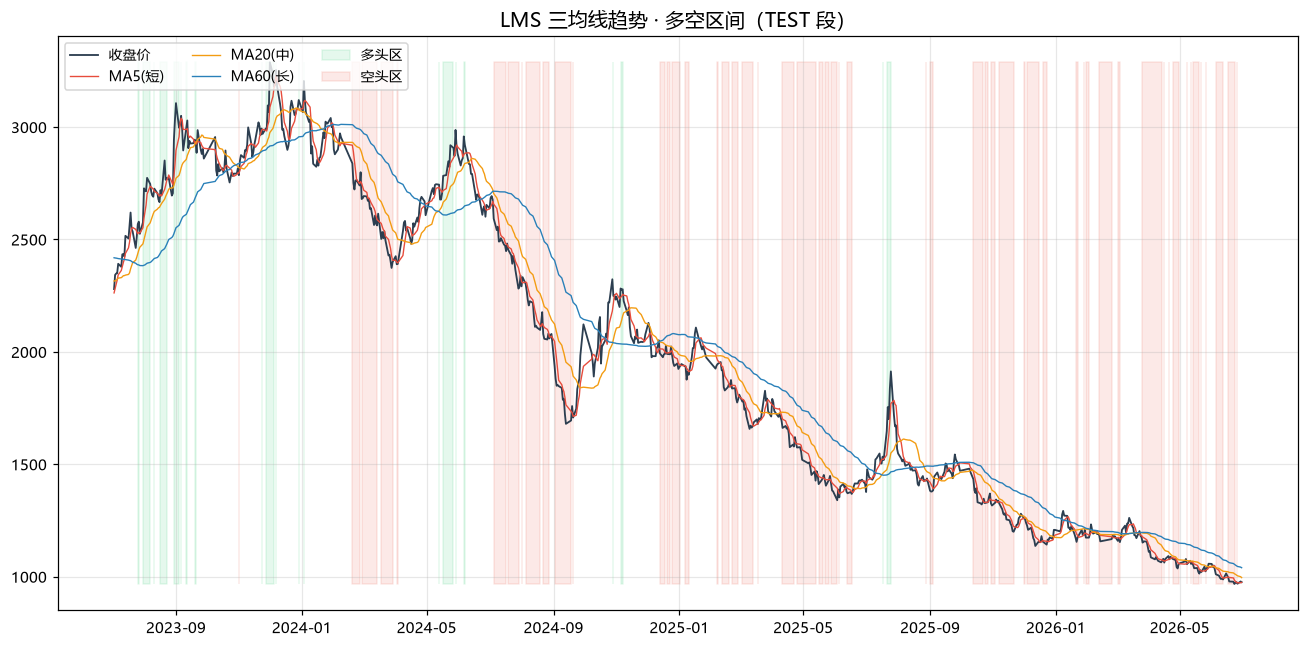

In [26]:
reg = lms.compute_lms_regime(df_pl).to_pandas()
mask = (reg["datetime"] >= pd.Timestamp(config.TEST_PERIOD[0])) & (reg["datetime"] <= pd.Timestamp(config.TEST_PERIOD[1]))
r = reg[mask].merge(raw[["datetime", "close"]], on="datetime")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(r["datetime"], r["close"], color="#2c3e50", lw=1.2, label="收盘价")
ax.plot(r["datetime"], r["ma_s"], color="#e74c3c", lw=.9, label=f"MA{config.LMS_SHORT}(短)")
ax.plot(r["datetime"], r["ma_m"], color="#f39c12", lw=.9, label=f"MA{config.LMS_MEDIUM}(中)")
ax.plot(r["datetime"], r["ma_l"], color="#2980b9", lw=.9, label=f"MA{config.LMS_LONG}(长)")
lo, hi = r["close"].min(), r["close"].max()
ax.fill_between(r["datetime"], lo, hi, where=r["lms_regime"] > 0, color="#2ecc71", alpha=.12, label="多头区")
ax.fill_between(r["datetime"], lo, hi, where=r["lms_regime"] < 0, color="#e74c3c", alpha=.12, label="空头区")
ax.set_title("LMS 三均线趋势 · 多空区间（TEST 段）", fontsize=13)
ax.legend(loc="upper left", ncol=3, fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8️⃣ 小结与后续 📝
- **模型**：`GlassLgbModel` 强正则 + TRAIN/VALID 合并训练，配合 **因果 z-score** 后处理，缓解过拟合与偏多偏差。
- **策略（推荐）**：**纯三均线 8/21/55** + 收盘在中均线上/下，样本外 TEST 约 **+73% / 年化 24% / 夏普 0.90**。
- **对比**：旧参数 5/20/60 纯规则约 +20%；加 AI 否决层反而拉低收益，不建议默认开启。
- **调参**：`config.LMS_SHORT/MEDIUM/LONG`、`POSITION_PCT`；`8/21/55` 在 TEST 段调优，存在过拟合风险。
- **流水线**：`python 03_backtest.py` 与 Notebook §6 逻辑一致。

> ⚠️ 本 Notebook 为量化研究示例，历史回测不代表未来；实盘需考虑真实成本、换月、涨跌停不可成交等因素。